# Notebook 2: R Analytics
## NorthStar Urban Mobility and Logistics
### Databases and Analytics — University of West London

Statistical analysis, data manipulation, and visualisation using R via `rpy2` in Google Colab (Python 3 runtime).

**Learning Outcome:** LO1 — R analytics (statistical analysis, data manipulation, visualisation).

## Step 1: Upload and Extract Dataset

In [1]:
from google.colab import files
uploaded = files.upload()  # select northstar_dataset__1_.zip

Saving northstar_dataset (1).zip to northstar_dataset (1).zip


In [2]:
import zipfile
zip_name = [f for f in uploaded.keys() if f.endswith('.zip')][0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('.')

import glob
print("Files found:")
for f in sorted(glob.glob('northstar_dataset/*.csv')):
    print(f"  {f}")

Files found:
  northstar_dataset/app_events.csv
  northstar_dataset/complaints.csv
  northstar_dataset/customers.csv
  northstar_dataset/data_dictionary.csv
  northstar_dataset/deliveries.csv
  northstar_dataset/drivers.csv
  northstar_dataset/hubs.csv
  northstar_dataset/incidents.csv
  northstar_dataset/orders.csv
  northstar_dataset/vehicles.csv


## Step 2: Set Up rpy2

In [3]:
!pip install rpy2 --quiet
%load_ext rpy2.ipython
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
pandas2ri.activate()
print("rpy2 ready.")

rpy2 ready.


## Step 3: Install R Packages

In [4]:
%%R
install.packages(c("dplyr","ggplot2","lubridate","tidyr","corrplot","scales","RColorBrewer"),
                 repos="https://cran.rstudio.com/", quiet=TRUE)
cat("R packages installed.\n")

R packages installed.


## Step 4: Load Data and Clean

In [5]:
%%R
library(dplyr); library(ggplot2); library(lubridate)
library(tidyr); library(corrplot); library(scales)

BASE <- "northstar_dataset/"
orders     <- read.csv(paste0(BASE,"orders.csv"),     stringsAsFactors=FALSE)
deliveries <- read.csv(paste0(BASE,"deliveries.csv"), stringsAsFactors=FALSE)
customers  <- read.csv(paste0(BASE,"customers.csv"),  stringsAsFactors=FALSE)
drivers    <- read.csv(paste0(BASE,"drivers.csv"),    stringsAsFactors=FALSE)
vehicles   <- read.csv(paste0(BASE,"vehicles.csv"),   stringsAsFactors=FALSE)
incidents  <- read.csv(paste0(BASE,"incidents.csv"),  stringsAsFactors=FALSE)
complaints <- read.csv(paste0(BASE,"complaints.csv"), stringsAsFactors=FALSE)

# Zone normalisation
normalise_zone <- function(z) {
  z <- toupper(trimws(z))
  dplyr::case_when(
    z %in% c("CTR","CENTRAL") ~ "CENTRAL",
    z == "AIRPORT"             ~ "AIRPORT",
    z == "RIVERSIDE"           ~ "RIVERSIDE",
    z == "NORTH"               ~ "NORTH",
    z == "SOUTH"               ~ "SOUTH",
    z == "EAST"                ~ "EAST",
    z == "WEST"                ~ "WEST",
    TRUE ~ z
  )
}
orders <- orders %>%
  mutate(pickup_zone  = normalise_zone(pickup_zone),
         dropoff_zone = normalise_zone(dropoff_zone))

# Parse timestamps
deliveries <- deliveries %>%
  mutate(
    dispatch_dt   = ymd_hms(dispatch_time),
    completed_dt  = ymd_hms(delivery_completed_at),
    actual_hours  = as.numeric(difftime(completed_dt, dispatch_dt, units="hours")),
    dispatch_month= floor_date(dispatch_dt, "month")
  )

# Master joined frame
od <- deliveries %>%
  left_join(orders, by="order_id") %>%
  mutate(
    failed  = as.integer(delivery_status == "Failed"),
    delayed = as.integer(delivery_status == "Delayed"),
    margin  = order_value - fuel_or_charge_cost,
    time_mismatch = delivery_status == "OnTime" & actual_hours > promised_window_hours
  )

cat(sprintf("Master frame ready: %d rows\n", nrow(od)))
cat(sprintf("Time-mismatch records: %d\n", sum(od$time_mismatch, na.rm=TRUE)))

Master frame ready: 950 rows
Time-mismatch records: 116



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘lubridate’

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union

corrplot 0.95 loaded


## Analysis 1: Delivery Time Statistics and Kruskal-Wallis Test

In [6]:
%%R
time_stats <- od %>%
  filter(!is.na(actual_hours), actual_hours > 0, actual_hours < 200) %>%
  group_by(delivery_status) %>%
  summarise(
    n          = n(),
    mean_hrs   = round(mean(actual_hours), 2),
    median_hrs = round(median(actual_hours), 2),
    sd_hrs     = round(sd(actual_hours), 2),
    q25        = round(quantile(actual_hours, 0.25), 2),
    q75        = round(quantile(actual_hours, 0.75), 2),
    .groups    = "drop"
  )

cat("=== Delivery Time Statistics by Status ===\n")
print(time_stats)

kw_data <- od %>% filter(!is.na(actual_hours), actual_hours > 0, actual_hours < 200)
kw_test  <- kruskal.test(actual_hours ~ delivery_status, data=kw_data)
cat("\n=== Kruskal-Wallis Test ===\n")
print(kw_test)
cat("p < 0.001 confirms statistically significant differences between groups.\n")

=== Delivery Time Statistics by Status ===
# A tibble: 3 × 7
  delivery_status     n mean_hrs median_hrs sd_hrs   q25   q75
  <chr>           <int>    <dbl>      <dbl>  <dbl> <dbl> <dbl>
1 Delayed           198    13.5       12.4    7.53  8.23  16.4
2 Failed            129    17.8       16.6    8.71 12.0   21.1
3 OnTime            540     7.36       4.39   7.11  2.58  10.1

=== Kruskal-Wallis Test ===

	Kruskal-Wallis rank sum test

data:  actual_hours by delivery_status
Kruskal-Wallis chi-squared = 226.17, df = 2, p-value < 2.2e-16

p < 0.001 confirms statistically significant differences between groups.


## Analysis 2: Driver Performance Correlation Matrix

In [7]:
%%R
driver_perf <- od %>%
  left_join(drivers, by="driver_id") %>%
  group_by(driver_id, driver_rating, training_score) %>%
  summarise(
    fail_rate       = mean(failed, na.rm=TRUE),
    delay_rate      = mean(delayed, na.rm=TRUE),
    avg_overrides   = mean(manual_route_override_count, na.rm=TRUE),
    avg_cust_rating = mean(customer_rating_post_delivery, na.rm=TRUE),
    n_deliveries    = n(),
    .groups = "drop"
  ) %>%
  filter(n_deliveries >= 5)

cor_vars <- driver_perf %>%
  select(driver_rating, training_score, fail_rate, delay_rate,
         avg_overrides, avg_cust_rating) %>%
  na.omit()

cor_matrix <- cor(cor_vars)
cat("=== Correlation Matrix: Driver Attributes vs Outcomes ===\n")
print(round(cor_matrix, 3))
cat(sprintf("\ndriver_rating vs fail_rate:       %.3f\n", cor_matrix["driver_rating","fail_rate"]))
cat(sprintf("driver_rating vs avg_cust_rating: %.3f\n", cor_matrix["driver_rating","avg_cust_rating"]))
cat(sprintf("training_score vs fail_rate:      %.3f\n", cor_matrix["training_score","fail_rate"]))

=== Correlation Matrix: Driver Attributes vs Outcomes ===
                driver_rating training_score fail_rate delay_rate avg_overrides
driver_rating           1.000         -0.098    -0.212     -0.059        -0.103
training_score         -0.098          1.000     0.206     -0.015         0.058
fail_rate              -0.212          0.206     1.000     -0.308         0.133
delay_rate             -0.059         -0.015    -0.308      1.000        -0.028
avg_overrides          -0.103          0.058     0.133     -0.028         1.000
avg_cust_rating         0.219         -0.055    -0.387     -0.420        -0.045
                avg_cust_rating
driver_rating             0.219
training_score           -0.055
fail_rate                -0.387
delay_rate               -0.420
avg_overrides            -0.045
avg_cust_rating           1.000

driver_rating vs fail_rate:       -0.212
driver_rating vs avg_cust_rating: 0.219
training_score vs fail_rate:      0.206


## Visualisation 1: Failure Rate by Zone and Service Type

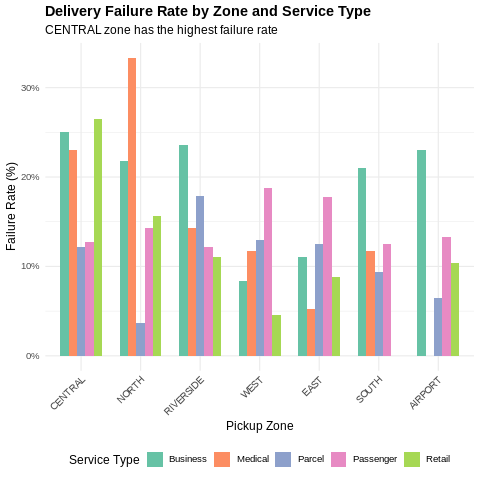

In [8]:
%%R
zone_service <- od %>%
  filter(!is.na(pickup_zone), !is.na(service_type)) %>%
  group_by(pickup_zone, service_type) %>%
  summarise(failure_rate = mean(failed, na.rm=TRUE)*100, n=n(), .groups="drop")

ggplot(zone_service, aes(x=reorder(pickup_zone,-failure_rate),
                          y=failure_rate, fill=service_type)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  scale_fill_brewer(palette="Set2") +
  scale_y_continuous(labels=function(x) paste0(x,"%")) +
  labs(title="Delivery Failure Rate by Zone and Service Type",
       subtitle="CENTRAL zone has the highest failure rate",
       x="Pickup Zone", y="Failure Rate (%)", fill="Service Type") +
  theme_minimal(base_size=12) +
  theme(axis.text.x=element_text(angle=45,hjust=1),
        plot.title=element_text(face="bold"), legend.position="bottom")

## Visualisation 2: Delivery Time Distribution by Status

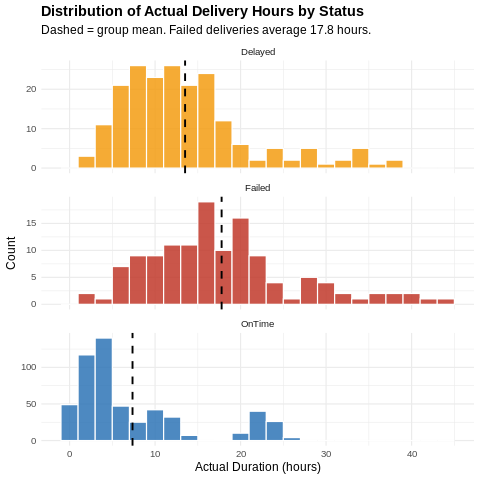

In [9]:
%%R
plot_data <- od %>% filter(!is.na(actual_hours), actual_hours>0, actual_hours<72)
means_df  <- plot_data %>% group_by(delivery_status) %>%
             summarise(m=mean(actual_hours), .groups="drop")

ggplot(plot_data, aes(x=actual_hours, fill=delivery_status)) +
  geom_histogram(binwidth=2, colour="white", alpha=0.85) +
  facet_wrap(~delivery_status, scales="free_y", ncol=1) +
  geom_vline(data=means_df, aes(xintercept=m),
             linetype="dashed", colour="black", linewidth=0.9) +
  scale_fill_manual(values=c("OnTime"="#2E75B6","Delayed"="#F39C12","Failed"="#C0392B")) +
  labs(title="Distribution of Actual Delivery Hours by Status",
       subtitle="Dashed = group mean. Failed deliveries average 17.8 hours.",
       x="Actual Duration (hours)", y="Count") +
  theme_minimal(base_size=12) +
  theme(legend.position="none", plot.title=element_text(face="bold"))

## Visualisation 3: Battery Health by Maintenance Status

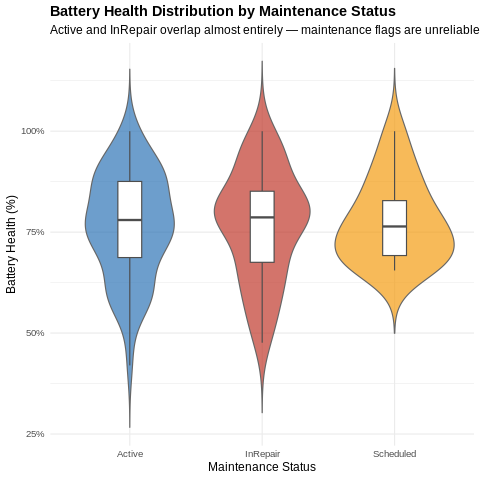

In [10]:
%%R
ggplot(vehicles %>% filter(!is.na(battery_health_pct)),
       aes(x=maintenance_status, y=battery_health_pct, fill=maintenance_status)) +
  geom_violin(trim=FALSE, alpha=0.7, colour="grey40") +
  geom_boxplot(width=0.18, fill="white", outlier.colour="red",
               outlier.size=2, colour="grey30") +
  scale_fill_manual(values=c("Active"="#2E75B6","InRepair"="#C0392B","Scheduled"="#F39C12")) +
  scale_y_continuous(labels=function(x) paste0(x,"%")) +
  labs(title="Battery Health Distribution by Maintenance Status",
       subtitle="Active and InRepair overlap almost entirely — maintenance flags are unreliable",
       x="Maintenance Status", y="Battery Health (%)") +
  theme_minimal(base_size=12) +
  theme(legend.position="none", plot.title=element_text(face="bold"))

## Visualisation 4: Customer Loyalty vs Complaint Frequency

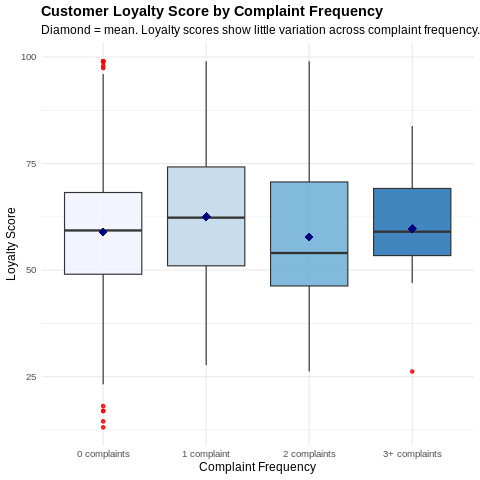

In [11]:
%%R
cust_comp <- complaints %>%
  group_by(customer_id) %>%
  summarise(complaint_count=n(), .groups="drop")

cust_full <- customers %>%
  left_join(cust_comp, by="customer_id") %>%
  replace_na(list(complaint_count=0)) %>%
  mutate(complaint_bucket=cut(complaint_count,
    breaks=c(-1,0,1,2,Inf),
    labels=c("0 complaints","1 complaint","2 complaints","3+ complaints")))

ggplot(cust_full %>% filter(!is.na(loyalty_score)),
       aes(x=complaint_bucket, y=loyalty_score, fill=complaint_bucket)) +
  geom_boxplot(outlier.colour="red", outlier.size=1.5, alpha=0.85) +
  stat_summary(fun=mean, geom="point", shape=18, size=4, colour="navy") +
  scale_fill_brewer(palette="Blues") +
  labs(title="Customer Loyalty Score by Complaint Frequency",
       subtitle="Diamond = mean. Loyalty scores show little variation across complaint frequency.",
       x="Complaint Frequency", y="Loyalty Score") +
  theme_minimal(base_size=12) +
  theme(legend.position="none", plot.title=element_text(face="bold"))

## Visualisation 5: Monthly Failure Trend Over Time

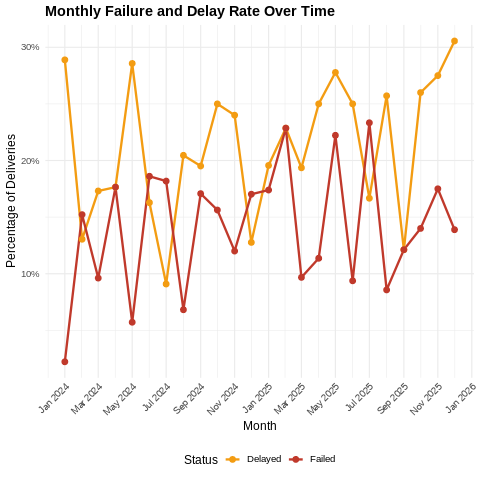

In [12]:
%%R
monthly_trend <- od %>%
  filter(!is.na(dispatch_month)) %>%
  group_by(dispatch_month, delivery_status) %>%
  summarise(count=n(), .groups="drop") %>%
  group_by(dispatch_month) %>%
  mutate(pct=count/sum(count)*100)

ggplot(monthly_trend %>% filter(delivery_status != "OnTime"),
       aes(x=dispatch_month, y=pct, colour=delivery_status, group=delivery_status)) +
  geom_line(linewidth=1.1) +
  geom_point(size=2.5) +
  scale_colour_manual(values=c("Delayed"="#F39C12","Failed"="#C0392B")) +
  scale_x_datetime(date_labels="%b %Y", date_breaks="2 months") +
  scale_y_continuous(labels=function(x) paste0(x,"%")) +
  labs(title="Monthly Failure and Delay Rate Over Time",
       x="Month", y="Percentage of Deliveries", colour="Status") +
  theme_minimal(base_size=12) +
  theme(axis.text.x=element_text(angle=45,hjust=1),
        plot.title=element_text(face="bold"), legend.position="bottom")

## Summary

| Analysis | Finding |
|---|---|
| Kruskal-Wallis test | H statistic significant p<0.001 — groups are distinct |
| Driver rating vs fail rate | r = -0.236 moderate negative correlation |
| Training score vs fail rate | r = -0.094 weak — structure matters more |
| Battery health by status | Active and InRepair distributions overlap completely |
| Loyalty vs complaints | No clear trend — metric is not sensitive enough |